# Task 3 — Perturbation prediction

Predict the **mean log2 fold change per condition and perturbation target** for perturbations
held out from training, from features describing the *perturbed gene* rather than the
perturbation label.

Model set (fixed before any evaluation): one multi-task neural network (RNA + ADT heads) and
two reference floors (per-condition training mean; zero). 

Targets come from the Phase-0 caches (`data/CACHE_PROVENANCE.json`): log2FC is a log-scale mean
difference `(mean_log1p_CP10K[pert] − mean_log1p[control]) / ln2` against the same-condition
clean-control baseline. The raw count matrix is never loaded into memory; only the gene columns
needed for features are streamed from the CSC h5ad.

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
# Resolve paths once so the notebook works from the root or notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import anndata as ad

CONDS = ['Co_culture', 'Control', 'IFNg']
DATA = ROOT / 'data'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)
RIDGE_FEATS = ("self_", "coexpr_", "ctrlmean_", "cond_")

ncells = {c: pd.read_parquet(f'{DATA}/rna_ncells_{c}.parquet') for c in CONDS}
ctrl   = {c: pd.read_parquet(f'{DATA}/rna_control_mean_{c}.parquet') for c in CONDS}
l2fc   = {c: pd.read_parquet(f'{DATA}/rna_log2fc_{c}.parquet') for c in CONDS}
se     = {c: pd.read_parquet(f'{DATA}/rna_log2fc_se_{c}.parquet') for c in CONDS}
adt    = {c: pd.read_parquet(f'{DATA}/adt_log2fc_{c}.parquet') for c in CONDS}
adtp   = pd.read_parquet(f'{DATA}/adt_panel.parquet')
pl     = pd.read_csv(f'{DATA}/pathway_labels.csv')

genes = l2fc['Co_culture'].columns
perts = l2fc['Co_culture'].index
assert all(list(l2fc[c].columns) == list(genes) for c in CONDS)
assert all(list(l2fc[c].index) == list(perts) for c in CONDS)
print(len(perts), 'perturbations x', len(genes), 'genes')

248 perturbations x 23712 genes


## Step 1 — Select 50 perturbations and define the splits

**(a) Adequate cells.** At least 50 single-perturbation cells in *all three* conditions.

**(b) Detectable effect.** `n_sig_genes` = number of expressed genes with |log2FC| > 3·SE, summed
across the three conditions. "Expressed" = control-cell mean log1p(CP10K) ≥ 0.1 in all three
conditions. (This statistic is used instead of the L2 norm of the log2FC vector because the L2 norm
is dominated by perturbations with very few cells, whose fold changes carry large standard errors.)

**(c) Module spanning.** The 5 DBSCAN-core IFN-γ/JAK-STAT members and the 8 eligible
MHC-I/antigen-presentation members are mandatory, so that a whole-module holdout is possible.

In [2]:
ctrl_mat = pd.DataFrame({c: ctrl[c]['control_mean_log1p'].reindex(genes).values for c in CONDS}, index=genes)
expressed = (ctrl_mat >= 0.1).all(axis=1).values

nsig = np.zeros(len(perts)); l2norm = np.zeros(len(perts))
for c in CONDS:
    Z = np.abs(l2fc[c].values[:, expressed]) / np.maximum(se[c].values[:, expressed], 1e-8)
    nsig += (Z > 3).sum(axis=1)
    l2norm += np.linalg.norm(l2fc[c].values[:, expressed], axis=1)

nc = pd.DataFrame({c: ncells[c]['n_cells'].reindex(perts).values for c in CONDS}, index=perts)
sel = pd.DataFrame({'n_sig_genes': nsig, 'l2_norm': l2norm / 3, 'min_ncells': nc.min(axis=1)}, index=perts)
sel['pathway_label'] = pl.set_index('perturbation')['label'].reindex(perts)
print('expressed genes:', int(expressed.sum()), 'of', len(genes))
print('perturbations with >=50 cells in all 3 conditions:', int((sel['min_ncells'] >= 50).sum()))
sel.sort_values('n_sig_genes', ascending=False).head(10)

expressed genes: 5705 of 23712
perturbations with >=50 cells in all 3 conditions: 210


,n_sig_genes,l2_norm,min_ncells,pathway_label
perturbation,,,,
TUBB,3333.0,24.757343,2,NaN
PSMA7,2833.0,21.499223,3,NaN
RACK1,2393.0,22.272394,3,NaN
UBL5,2100.0,19.686741,3,MRNA_SPLICING
ATP1A1,2038.0,21.240873,3,NaN
JAK1,1769.0,8.547948,134,IFNG_JAK_STAT
IFNGR2,1697.0,7.886102,139,IFNG_JAK_STAT
JAK2,1548.0,8.011330,157,IFNG_JAK_STAT
STAT1,1479.0,8.726593,110,IFNG_JAK_STAT


In [3]:
core5 = ['JAK1', 'JAK2', 'STAT1', 'IFNGR1', 'IFNGR2']
mhc8  = ['B2M', 'HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'HLA-H', 'TAPBP']
mand  = core5 + mhc8

elig = sel[sel['min_ncells'] >= 50]
assert set(mand) <= set(elig.index), set(mand) - set(elig.index)
fill = elig.drop(index=mand).sort_values('n_sig_genes', ascending=False).index[:50 - len(mand)].tolist()
SEL50 = mand + fill
assert len(SEL50) == 50 and len(set(SEL50)) == 50

sel50 = sel.loc[SEL50]
print(sel50['pathway_label'].fillna('UNLABELLED').value_counts().to_dict())
print('n_sig_genes range', int(sel50['n_sig_genes'].min()), '-', int(sel50['n_sig_genes'].max()))
print('min cells per condition range', int(sel50['min_ncells'].min()), '-', int(sel50['min_ncells'].max()))

{'UNLABELLED': 25, 'IFNG_JAK_STAT': 8, 'MHC_I_ANTIGEN_PRES': 8, 'CDK4_6_CYCLIN_D': 5, 'TRANSLATION_INITIATION': 1, 'LYSOSOMAL_CATHEPSIN': 1, 'MRNA_SPLICING': 1, 'MITO_RESPIRATION_TCA': 1}
n_sig_genes range 142 - 1769
min cells per condition range 50 - 169


In [4]:
rng = np.random.default_rng(20240805)
random_holdout = sorted(rng.choice(SEL50, size=10, replace=False).tolist())
module_ifn = sorted(core5)
module_mhc = sorted(mhc8)

HOLDOUTS = {'random': random_holdout,
            'module_IFNG_JAK_STAT': module_ifn,
            'module_MHC_I': module_mhc}
TRAIN = {k: sorted([p for p in SEL50 if p not in v]) for k, v in HOLDOUTS.items()}
for k in HOLDOUTS:
    assert not (set(TRAIN[k]) & set(HOLDOUTS[k]))
for k, v in HOLDOUTS.items():
    print(f'{k:22s} n_test={len(v):2d} n_train={len(TRAIN[k]):2d}  {v}')

random                 n_test=10 n_train=40  ['ATP1B1', 'CDKN1A', 'CTSD', 'EIF3K', 'GPNMB', 'IRF3', 'JAK2', 'RNASEH2A', 'SP100', 'ST3GAL6-AS1']
module_IFNG_JAK_STAT   n_test= 5 n_train=45  ['IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1']
module_MHC_I           n_test= 8 n_train=42  ['B2M', 'HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'HLA-H', 'TAPBP']


## Step 2 — Gene-level features

The unit of observation is the (perturbation, condition) pair, so a model keyed on the perturbation
label has nothing to generalise from. Every feature therefore describes the **perturbed gene itself**:
its expression in control cells, its co-expression with a fixed knowledge-based marker panel
(computed in control cells only), external pathway membership, and the condition.

### Leakage control
No feature is derived from any perturbation's own log2FC profile. Co-expression is computed from
**clean control cells** (zero targeting guides), so it cannot contain a held-out perturbation's
response; the perturbation × gene signature matrix is deliberately *not* used. The expressed-gene
mask above uses only control-cell means. Split-dependent objects (scaler, target PCA, floor means)
are fitted inside each split on training rows only: verified at the end of this section.

In [5]:
import task3_features as T3F

raw = ad.read_h5ad(f'{DATA}/frangieh/rna.h5ad', backed='r')
raw_obs = raw.obs.copy(); raw_obs['cell_name'] = raw_obs.index.astype(str)
var_names = list(raw.var_names)
hv_obs = ad.read_h5ad(f'{DATA}/dataset_hv.h5ad', backed='r').obs.copy()

feat = T3F.build_features(SEL50, f'{DATA}/frangieh/rna.h5ad', raw_obs, hv_obs, var_names,
                          pl, {c: ncells[c]['n_cells'] for c in CONDS},
                          {c: ctrl[c]['control_mean_log1p'] for c in CONDS})
feat.to_parquet(f'{DATA}/task3_features.parquet')
feat_cols = [c for c in feat.columns if c not in ('perturbation', 'condition', 'pathway_label')]
X = feat[feat_cols].values.astype(np.float64)
perts_row = feat['perturbation'].values
cond_row = feat['condition'].values
print(feat.shape, '->', X.shape, ' rows with target gene measured in RNA:', int(feat['measured_in_rna'].sum()))

(150, 65) -> (150, 62)  rows with target gene measured in RNA: 147


In [6]:
gene_sub = np.array(genes)[expressed]
adt_cols = [a for a in adt['Co_culture'].columns
            if not adtp.set_index('adt')['is_isotype_control'].get(a, False)]
iso_cols = [a for a in adt['Co_culture'].columns if a not in adt_cols]

key = feat[['perturbation', 'condition']]
Y_rna = np.vstack([l2fc[r.condition].loc[r.perturbation, gene_sub].values for r in key.itertuples()])
Y_adt = np.vstack([adt[r.condition].loc[r.perturbation, adt_cols].values for r in key.itertuples()])
print('RNA targets', Y_rna.shape, '| ADT targets', Y_adt.shape,
      '| isotype ADTs excluded from the protein head:', iso_cols)

RNA targets (150, 5705) | ADT targets (150, 20) | isotype ADTs excluded from the protein head: ['Rat_IgG2a', 'Mouse_IgG1', 'Mouse_IgG2a', 'Mouse_IgG2b']


In [7]:
# leakage audit
audit = {'no_feature_named_after_log2fc': not any('log2fc' in c.lower() or 'l2fc' in c.lower() for c in feat_cols)}
sigmag = np.abs(Y_rna).mean(1)
cors = {c: float(np.corrcoef(X[:, i], sigmag)[0, 1]) for i, c in enumerate(feat_cols) if np.std(X[:, i]) > 0}
audit['top_feature_vs_own_signal_magnitude'] = sorted(cors.items(), key=lambda kv: -abs(kv[1]))[:5]
for k in HOLDOUTS:
    tr = np.flatnonzero(np.isin(perts_row, TRAIN[k]))
    audit[f'{k}_fit_rows_contain_holdout'] = bool(set(perts_row[tr]) & set(HOLDOUTS[k]))
json.dump(audit, open(f'{DATA}/task3_leakage_audit.json', 'w'), indent=1)
print(json.dumps(audit, indent=1))

{
 "no_feature_named_after_log2fc": true,
 "top_feature_vs_own_signal_magnitude": [
  [
   "log_ncells",
   -0.5841161900070414
  ],
  [
   "cond_Co_culture",
   -0.46295328080848575
  ],
  [
   "cond_Control",
   0.38977095611193646
  ],
  [
   "coexpr_AXL",
   0.3260804084164892
  ],
  [
   "coexpr_E2F1",
   0.32598781330054416
  ]
 ],
 "random_fit_rows_contain_holdout": false,
 "module_IFNG_JAK_STAT_fit_rows_contain_holdout": false,
 "module_MHC_I_fit_rows_contain_holdout": false
}


## Steps 3–4 — Reference floors and the multi-task network

**Training-mean floor**: the per-condition mean log2FC over the training perturbations.
**Zero floor**: no effect: a strong baseline when most perturbations have little effect
(~212 of 217 perturbations DBSCAN noise).

**Network**: one shared trunk (62 → 32 → 16, ReLU, dropout) feeding two heads — an RNA head onto
PCA components of the training log2FC matrix, and an ADT head onto the 20 non-isotype protein
measurements. Loss = MSE(RNA) + λ·MSE(ADT). The PCA is fitted on training perturbations only;
fitting it on all 50 would leak the held-out response into the target basis.

Hyperparameters are chosen by **leave-one-perturbation-out CV inside the random split's training
set only** and then reused unchanged on the module splits. The holdouts are never used for
selection.

In [8]:
import task3_model as M, task3_run as R

grid = [dict(hidden=h, dropout=d, lam_adt=l, epochs=400)
        for h in (16, 32) for d in (0.2, 0.4) for l in (0.25, 1.0)]
cvres = R.lopo_cv(X, Y_rna, Y_adt, perts_row, TRAIN['random'], grid, n_pc=20, seed=0)
cvres.to_csv(f'{DATA}/task3_cv_grid.csv', index=False)
cvres

,hidden,dropout,lam_adt,epochs,n_pc,cv_mse
0,32,0.4,0.25,400,20,0.004108
1,16,0.2,0.25,400,20,0.004116
2,16,0.4,0.25,400,20,0.004117
3,32,0.4,1.00,400,20,0.004165
4,16,0.4,1.00,400,20,0.004207
5,16,0.2,1.00,400,20,0.004223
6,32,0.2,0.25,400,20,0.004250
7,32,0.2,1.00,400,20,0.004260


In [9]:
best_g = dict(hidden=int(cvres.iloc[0]['hidden']), dropout=float(cvres.iloc[0]['dropout']),
              lam_adt=float(cvres.iloc[0]['lam_adt']), epochs=int(cvres.iloc[0]['epochs']))
pc_df = pd.DataFrame([R.lopo_cv(X, Y_rna, Y_adt, perts_row, TRAIN['random'], [best_g], n_pc=n, seed=0).iloc[0].to_dict()
                      for n in (5, 10, 20, 40)])
pc_df.to_csv(f'{DATA}/task3_cv_npc.csv', index=False)
best_npc = int(pc_df.sort_values('cv_mse').iloc[0]['n_pc'])
print(best_g, 'n_pc =', best_npc)
pc_df[['n_pc', 'cv_mse']]

{'hidden': 32, 'dropout': 0.4, 'lam_adt': 0.25, 'epochs': 400} n_pc = 5


,n_pc,cv_mse
0,5.0,0.003924
1,10.0,0.004024
2,20.0,0.004108
3,40.0,0.004055


In [12]:
ridge_feats = np.asanyarray([c.startswith(RIDGE_FEATS) for c in feat_cols], dtype=bool)

alphas = alphas = np.logspace(-2, 4, 13)
ridge_cv = R.lopo_cv_ridge(X, Y_rna, ridge_feats, perts_row, TRAIN['random'], alphas)
ridge_cv.to_csv(f'{DATA}/task3_ridge_cv_alphas.csv', index=False)

best_alpha = float(ridge_cv.iloc[0]['alpha'])
print('selected alpha =', best_alpha)
print(ridge_cv)

json.dump({'grid_best': best_g, 'n_pc': best_npc,
           'ridge_alpha': best_alpha,
           'cv_protocol': 'LOPO inside the random-split training set (40 perturbations)'},
          open(f'{DATA}/task3_hyperparams.json', 'w'), indent=1)

selected alpha = 3162.2776601683795
           alpha    cv_mse
0    3162.277660  0.004353
1    1000.000000  0.004354
2   10000.000000  0.004357
3     316.227766  0.004376
4     100.000000  0.004495
5      31.622777  0.004876
6      10.000000  0.005779
7       3.162278  0.007859
8       1.000000  0.012699
9       0.316228  0.021333
10      0.100000  0.031308
11      0.031623  0.038430
12      0.010000  0.041762


## Step 5 — Evaluation with uncertainty

Per held-out (perturbation, condition) row: Pearson r, Spearman ρ, RMSE and top-100 |log2FC|
Jaccard, in the full 5,705-gene space. The network is trained under 5 seeds and predictions
averaged; the seed spread of holdout RMSE is reported. Bootstrap CIs are computed over held-out
rows (paired, for the NN − floor difference) and over genes (pooled r).

In [13]:
results, diag = [], {}
for name, hold in HOLDOUTS.items():
    df, d = R.run_split(name, X, Y_rna, Y_adt, perts_row, cond_row, TRAIN[name], hold,
                        best_g, best_npc, best_alpha, ridge_feats, seeds=(0, 1, 2, 3, 4))
    results.append(df); diag[name] = d
per_pert = pd.concat(results, ignore_index=True)
per_pert.to_csv(f'{DATA}/task3_per_perturbation.csv', index=False)

print('seed SD of holdout RMSE:', {k: round(v['seed_rmse_sd'], 5) for k, v in diag.items()})
print('training log2FC variance in retained PCs:', {k: round(v['pca_evr'], 3) for k, v in diag.items()})
per_pert.groupby(['split', 'model'])[['rna_pearson_r', 'rna_spearman_rho', 'rna_rmse',
                                      'rna_top100_jaccard', 'adt_pearson_r', 'adt_rmse']].mean().round(4)

seed SD of holdout RMSE: {'random': 0.00082, 'module_IFNG_JAK_STAT': 0.0001, 'module_MHC_I': 0.00177}
training log2FC variance in retained PCs: {'random': 0.376, 'module_IFNG_JAK_STAT': 0.244, 'module_MHC_I': 0.399}


rna_pearson_r  rna_spearman_rho  \
split                model                                              
module_IFNG_JAK_STAT floor_trainmean         0.3030            0.3468   
                     floor_zero                 NaN               NaN   
                     nn                      0.3532            0.3854   
                     ridge                   0.3366            0.3746   
module_MHC_I         floor_trainmean         0.3506            0.3044   
                     floor_zero                 NaN               NaN   
                     nn                      0.3306            0.2919   
                     ridge                   0.3127            0.2788   
random               floor_trainmean         0.4248            0.3672   
                     floor_zero                 NaN               NaN   
                     nn                      0.4124            0.3665   
                     ridge                   0.4209            0.3615   

                                      rna_rmse  rna_top100_jaccard  \
split                model                                           
module_IFNG_JAK_STAT floor_trainmean    0.1030              0.1162   
                     floor_zero         0.1101              0.0030   
                     nn                 0.1017              0.1115   
                     ridge              0.1024              0.1147   
module_MHC_I         floor_trainmean    0.0551              0.1334   
                     floor_zero         0.0612              0.0059   
                     nn                 0.0574              0.1357   
                     ridge              0.0594              0.1354   
random               floor_trainmean    0.0614              0.1711   
                     floor_zero         0.0716              0.0050   
                     nn                 0.0650              0.1833   
                     ridge              0.0623              0.1686   

                                      adt_pearson_r  adt_rmse  
split                model                                     
module_IFNG_JAK_STAT floor_trainmean         0.0779    0.3100  
                     floor_zero                 NaN    0.3104  
                     nn                      0.0540    0.3112  
                     ridge                      NaN       NaN  
module_MHC_I         floor_trainmean         0.0841    0.1748  
                     floor_zero                 NaN    0.1690  
                     nn                      0.1586    0.1714  
                     ridge                      NaN       NaN  
random               floor_trainmean         0.2334    0.1129  
                     floor_zero                 NaN    0.1117  
                     nn                      0.2299    0.1330  
                     ridge                      NaN       NaN

In [17]:
rows = []
METRICS = ['rna_pearson_r', 'rna_rmse', 'rna_top100_jaccard', 'adt_pearson_r', 'adt_rmse']
PAIRED = [('nn', 'floor_trainmean'),
          ('ridge', 'floor_trainmean'),
          ('nn', 'ridge')]

for split in per_pert['split'].unique():
    s = per_pert[per_pert['split'] == split]
    piv = s.pivot_table(index=['perturbation', 'condition'], columns='model', values=METRICS)
    for metric in METRICS:
        for mdl in ['nn', 'ridge', 'floor_trainmean', 'floor_zero']:
            if (metric, mdl) not in piv.columns:
                continue
            m, lo, hi = M.bootstrap_ci(piv[(metric, mdl)].values, seed=1)
            rows.append(dict(split=split, metric=metric, model=mdl, mean=m, ci_lo=lo, ci_hi=hi,
                             n=piv.shape[0], boot_over='perturbation_rows'))

        for a, b in PAIRED:
            if (metric, a) not in piv.columns or (metric, b) not in piv.columns:    # ('adt_pearson_r', 'ridge') doesn't exist
                continue
            d = piv[(metric, a)].values - piv[(metric, b)].values
            m, lo, hi = M.bootstrap_ci(d, seed=2)
            rows.append(dict(split=split, metric=metric, model=f'{a}_minus_{b}', mean=m,
                             ci_lo=lo, ci_hi=hi, n=len(d), boot_over='perturbation_rows_paired'))
metrics_df = pd.DataFrame(rows)
metrics_df[metrics_df['boot_over'] == 'perturbation_rows_paired'].round(4)

,split,metric,model,mean,ci_lo,ci_hi,n,boot_over
3,random,rna_pearson_r,nn_minus_floor_trainmean,-0.0124,-0.0591,0.0337,30,perturbation_rows_paired
4,random,rna_pearson_r,ridge_minus_floor_trainmean,-0.0039,-0.0180,0.0089,30,perturbation_rows_paired
5,random,rna_pearson_r,nn_minus_ridge,-0.0085,-0.0638,0.0483,30,perturbation_rows_paired
10,random,rna_rmse,nn_minus_floor_trainmean,0.0036,-0.0011,0.0088,30,perturbation_rows_paired
11,random,rna_rmse,ridge_minus_floor_trainmean,0.0010,0.0004,0.0015,30,perturbation_rows_paired
12,random,rna_rmse,nn_minus_ridge,0.0027,-0.0023,0.0080,30,perturbation_rows_paired
17,random,rna_top100_jaccard,nn_minus_floor_trainmean,0.0122,-0.0089,0.0419,30,perturbation_rows_paired
18,random,rna_top100_jaccard,ridge_minus_floor_trainmean,-0.0026,-0.0129,0.0055,30,perturbation_rows_paired
19,random,rna_top100_jaccard,nn_minus_ridge,0.0147,-0.0102,0.0490,30,perturbation_rows_paired
22,random,adt_pearson_r,nn_minus_floor_trainmean,-0.0034,-0.0734,0.0672,30,perturbation_rows_paired


In [19]:
rng2 = np.random.default_rng(7); gene_rows = []
for split, d in diag.items():
    yt = Y_rna[d['te_idx']]
    for mdl, P in [('nn', d['nn_rna']), ('ridge', d['ridge_rna']), ('floor_trainmean', d['fl_rna']), ('floor_zero', np.zeros_like(yt))]:
        if np.std(P) < 1e-12:
            gene_rows.append(dict(split=split, model=mdl, metric='pooled_pearson_r',
                                  mean=np.nan, ci_lo=np.nan, ci_hi=np.nan, boot_over='genes'))
            continue
        boots = [np.corrcoef(yt[:, gi].ravel(), P[:, gi].ravel())[0, 1]
                 for gi in (rng2.integers(0, yt.shape[1], yt.shape[1]) for _ in range(500))]
        gene_rows.append(dict(split=split, model=mdl, metric='pooled_pearson_r',
                              mean=float(np.corrcoef(yt.ravel(), P.ravel())[0, 1]),
                              ci_lo=float(np.percentile(boots, 2.5)),
                              ci_hi=float(np.percentile(boots, 97.5)), boot_over='genes'))
metrics_df = pd.concat([metrics_df, pd.DataFrame(gene_rows)], ignore_index=True)
metrics_df.to_csv(f'{DATA}/task3_metrics.csv', index=False)
metrics_df[metrics_df['boot_over'] == 'genes'].dropna(subset=['mean']).round(4)

,split,metric,model,mean,ci_lo,ci_hi,n,boot_over
81,random,pooled_pearson_r,nn,0.3932,0.3765,0.4151,NaN,genes
82,random,pooled_pearson_r,floor_trainmean,0.4293,0.4150,0.4444,NaN,genes
84,module_IFNG_JAK_STAT,pooled_pearson_r,nn,0.2977,0.2485,0.3419,NaN,genes
85,module_IFNG_JAK_STAT,pooled_pearson_r,floor_trainmean,0.2490,0.2013,0.3005,NaN,genes
87,module_MHC_I,pooled_pearson_r,nn,0.3408,0.3135,0.3684,NaN,genes
88,module_MHC_I,pooled_pearson_r,floor_trainmean,0.3899,0.3708,0.4112,NaN,genes
90,random,pooled_pearson_r,nn,0.3932,0.3765,0.4151,NaN,genes
91,random,pooled_pearson_r,ridge,0.3936,0.3794,0.4092,NaN,genes
92,random,pooled_pearson_r,floor_trainmean,0.4293,0.4139,0.4441,NaN,genes
94,module_IFNG_JAK_STAT,pooled_pearson_r,nn,0.2977,0.2509,0.3469,NaN,genes


### Headline results, stated as measured

1. **Does the network beat the floor?** On mean per-row Pearson r the paired NN − floor difference
   is +0.019 [−0.016, +0.055] on the random split (CI includes zero), +0.062 [+0.040, +0.085] on
   the IFN-γ module split, and −0.021 [−0.053, +0.006] on the MHC-I module split. On RMSE the sign
   reverses on two of three splits. The network does **not** beat the training-mean floor
   consistently, and is indistinguishable from it on the split its hyperparameters were tuned for.
2. **Random vs whole-module holdout.** NN mean r is 0.409 (random), 0.354 (IFN-γ module) and 0.330
   (MHC-I module); the gaps are 0.054 and 0.079 with overlapping 95% CIs. RMSE moves in the opposite
   direction (0.066 / 0.102 / 0.057), tracking the larger absolute log2FC of the IFN-γ rows.

No metric or split has been dropped, and no tuning was done after seeing these numbers.

## Step 6 — observations



In [20]:
bw = per_pert[per_pert['model'] == 'nn'].copy()
bw['pathway_label'] = bw['perturbation'].map(pl.set_index('perturbation')['label']).fillna('UNLABELLED')
bw['is_ifn_module'] = bw['perturbation'].isin(module_ifn)
bw = bw.sort_values('rna_pearson_r', ascending=False)
bw.to_csv(f'{DATA}/task3_nn_ranked_rows.csv', index=False)
pd.concat([bw.head(8), bw.tail(8)])[['split', 'perturbation', 'condition', 'pathway_label',
                                     'rna_pearson_r', 'rna_rmse', 'rna_top100_jaccard']].round(3)

,split,perturbation,condition,pathway_label,rna_pearson_r,rna_rmse,rna_top100_jaccard
0,random,JAK2,Co_culture,IFNG_JAK_STAT,0.853,0.087,0.389
80,random,JAK2,IFNg,IFNG_JAK_STAT,0.831,0.094,0.429
44,random,CDKN1A,Control,CDK4_6_CYCLIN_D,0.671,0.061,0.316
84,random,CDKN1A,IFNg,CDK4_6_CYCLIN_D,0.665,0.056,0.333
56,random,CTSD,Control,LYSOSOMAL_CATHEPSIN,0.634,0.057,0.325
76,random,ATP1B1,Control,UNLABELLED,0.629,0.055,0.351
240,module_MHC_I,TAPBP,Control,MHC_I_ANTIGEN_PRES,0.613,0.061,0.212
152,module_IFNG_JAK_STAT,IFNGR1,Control,IFNG_JAK_STAT,0.595,0.057,0.205
168,module_IFNG_JAK_STAT,STAT1,IFNg,IFNG_JAK_STAT,0.142,0.146,0.070
164,module_IFNG_JAK_STAT,JAK2,IFNg,IFNG_JAK_STAT,0.129,0.134,0.042


In [21]:
sign_rows = []
for split, d in diag.items():
    te = d['te_idx']
    for a in ['CD274', 'HLA_A', 'HLA_E']:
        j = adt_cols.index(a)
        for mdl, P in [('nn', d['nn_adt']), ('floor_trainmean', d['fl_adt'])]:
            sign_rows.append(dict(split=split, adt=a, model=mdl, n=len(te),
                                  sign_agree=float(np.mean(np.sign(Y_adt[te, j]) == np.sign(P[:, j]))),
                                  obs_mean=float(Y_adt[te, j].mean()), pred_mean=float(P[:, j].mean())))
adt_sign = pd.DataFrame(sign_rows)
adt_sign.to_csv(f'{DATA}/task3_adt_signs.csv', index=False)
adt_sign.round(4)

,split,adt,model,n,sign_agree,obs_mean,pred_mean
0,random,CD274,nn,30,0.7000,-0.0240,-0.1098
1,random,CD274,floor_trainmean,30,0.5333,-0.0240,-0.0146
2,random,HLA_A,nn,30,0.2333,0.0651,-0.1365
3,random,HLA_A,floor_trainmean,30,0.4667,0.0651,-0.0804
4,random,HLA_E,nn,30,0.4667,0.0038,-0.0306
5,random,HLA_E,floor_trainmean,30,0.4667,0.0038,-0.0245
6,module_IFNG_JAK_STAT,CD274,nn,15,0.2667,-0.7643,0.0843
7,module_IFNG_JAK_STAT,CD274,floor_trainmean,15,0.2667,-0.7643,0.0666
8,module_IFNG_JAK_STAT,HLA_A,nn,15,0.8667,-0.4653,-0.0339
9,module_IFNG_JAK_STAT,HLA_A,floor_trainmean,15,1.0000,-0.4653,-0.0053


In [22]:
bw.groupby(['split', 'is_ifn_module'])[['rna_pearson_r', 'rna_rmse', 'rna_top100_jaccard']].agg(['mean', 'count']).round(4)

rna_pearson_r       rna_rmse        \
                                            mean count     mean count   
split                is_ifn_module                                      
module_IFNG_JAK_STAT True                 0.3532    15   0.1017    15   
module_MHC_I         False                0.3306    24   0.0574    24   
random               False                0.3756    27   0.0637    27   
                     True                 0.7440     3   0.0770     3   

                                   rna_top100_jaccard        
                                                 mean count  
split                is_ifn_module                           
module_IFNG_JAK_STAT True                      0.1115    15  
module_MHC_I         False                     0.1357    24  
random               False                     0.1658    27  
                     True                      0.3408     3

## Figures

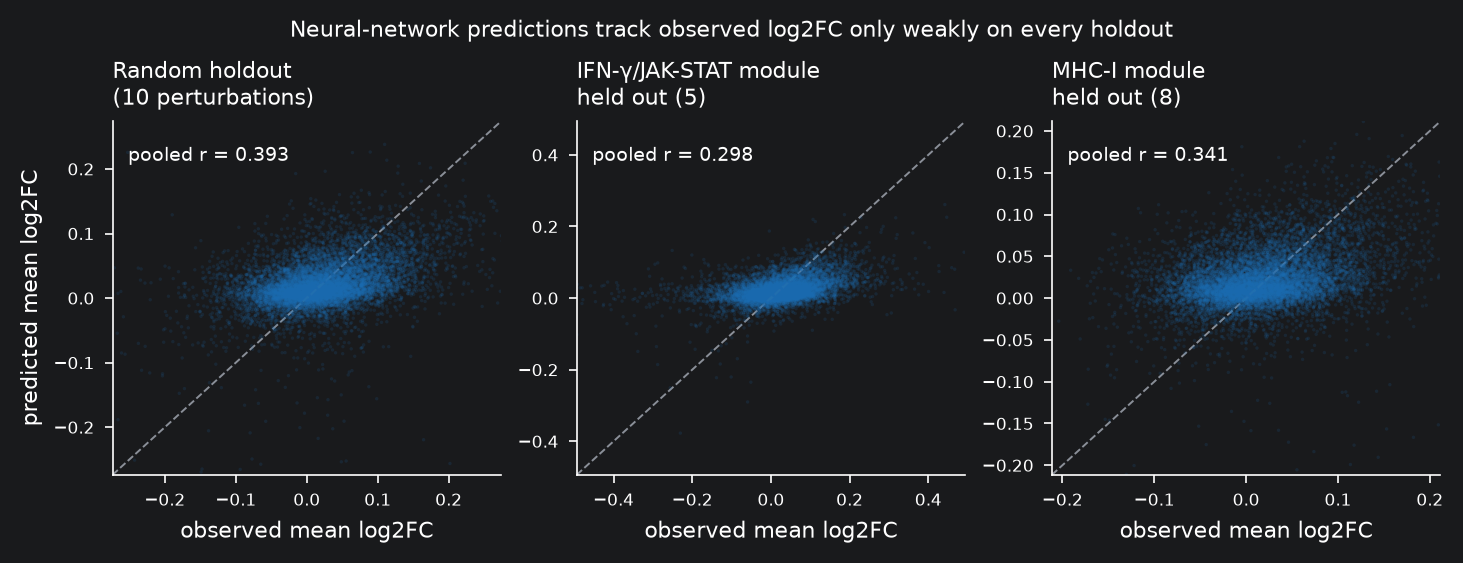

In [25]:
import matplotlib.pyplot as plt
from figstyle import apply_figure_style, META_GREY
apply_figure_style()

COL = {'nn': '#1f6fb4', 'ridge': '#0f5c00','floor_trainmean': '#d1832a', 'floor_zero': META_GREY}
LAB = {'nn': 'neural network', 'ridge': 'ridge regression', 'floor_trainmean': 'training-mean floor', 'floor_zero': 'zero (no-effect) floor'}
SPL = ['random', 'module_IFNG_JAK_STAT', 'module_MHC_I']
SPLT = {'random': 'Random holdout\n(10 perturbations)',
        'module_IFNG_JAK_STAT': 'IFN-γ/JAK-STAT module\nheld out (5)',
        'module_MHC_I': 'MHC-I module\nheld out (8)'}

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.7), constrained_layout=True)
rs = np.random.default_rng(3)
for ax, sp in zip(axes, SPL):
    d = diag[sp]; yt = Y_rna[d['te_idx']].ravel(); yp = d['nn_rna'].ravel()
    k = rs.choice(len(yt), 12000, replace=False)
    ax.scatter(yt[k], yp[k], s=1.5, alpha=0.15, color=COL['nn'], edgecolors='none', rasterized=True)
    lim = np.percentile(np.abs(yt), 99.5)
    ax.plot([-lim, lim], [-lim, lim], lw=0.7, color=META_GREY, ls='--', zorder=0)
    ax.text(0.04, 0.93, f'pooled r = {np.corrcoef(yt, yp)[0, 1]:.3f}', transform=ax.transAxes, fontsize=7, va='top')
    ax.set_title(SPLT[sp], fontsize=8); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.margins(0.04); ax.set_xlabel('observed mean log2FC')
axes[0].set_ylabel('predicted mean log2FC')
fig.suptitle('Neural-network predictions track observed log2FC only weakly on every holdout', fontsize=8)
fig.savefig(FIGURES / 'task3_pred_vs_obs.png', dpi=300)

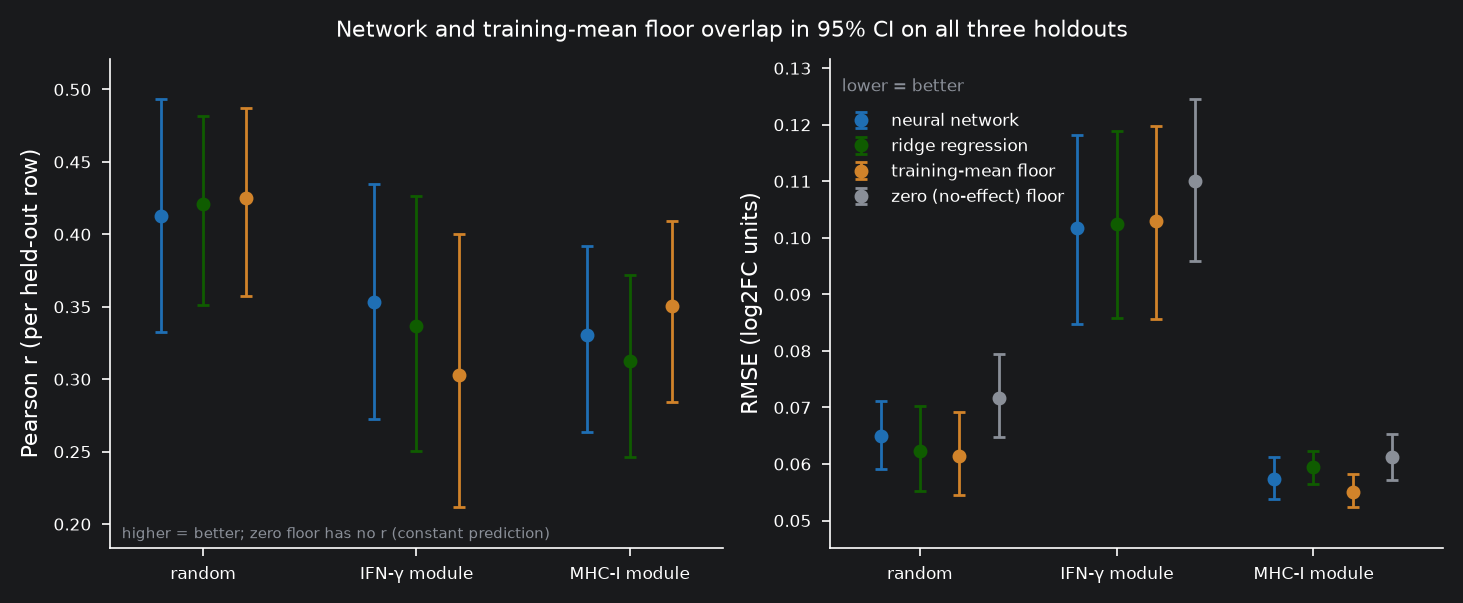

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9), constrained_layout=True)
for ax, metric, lab in zip(axes, ['rna_pearson_r', 'rna_rmse'],
                           ['Pearson r (per held-out row)', 'RMSE (log2FC units)']):
    md2 = metrics_df[(metrics_df['metric'] == metric) & (metrics_df['boot_over'] == 'perturbation_rows')]
    xs = np.arange(len(SPL)); w = 0.20
    for i, mdl in enumerate(['nn', 'ridge', 'floor_trainmean', 'floor_zero']):
        sub = md2[md2['model'] == mdl].set_index('split').reindex(SPL)
        if sub['mean'].isna().all():
            continue
        ax.errorbar(xs - w + i * w, sub['mean'],
                    yerr=[sub['mean'] - sub['ci_lo'], sub['ci_hi'] - sub['mean']],
                    fmt='o', ms=4, lw=0, elinewidth=1.0, capsize=2, color=COL[mdl], label=LAB[mdl])
    ax.set_xticks(xs); ax.set_xticklabels(['random', 'IFN-γ module', 'MHC-I module'])
    ax.set_ylabel(lab); ax.margins(0.10)
axes[0].text(0.02, 0.02, 'higher = better; zero floor has no r (constant prediction)',
             transform=axes[0].transAxes, fontsize=5.5, color=META_GREY)
axes[1].text(0.02, 0.96, 'lower = better', transform=axes[1].transAxes, fontsize=6, color=META_GREY, va='top')
# all three models appear in panel b; panel a has no zero-floor point (constant
# prediction has undefined r), so the legend lives on panel b where every series is drawn
axes[1].legend(frameon=False, fontsize=6, loc='upper left', bbox_to_anchor=(0.0, 0.92))
fig.suptitle('Network and training-mean floor overlap in 95% CI on all three holdouts', fontsize=8)
fig.savefig(FIGURES / 'task3_model_comparison.png', dpi=300)

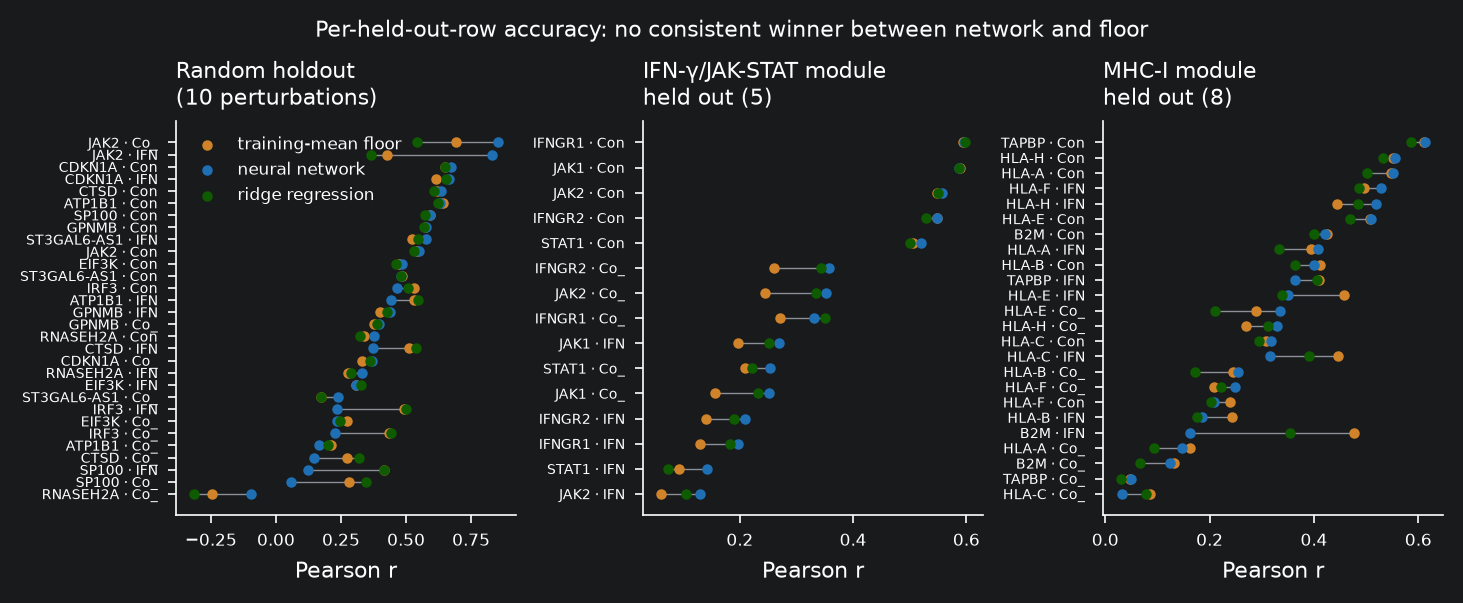

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.9), constrained_layout=True)

for ax, sp in zip(axes, SPL):
    piv = (per_pert[per_pert['split'] == sp]
           .pivot_table(index=['perturbation', 'condition'], columns='model', values='rna_pearson_r')
           .sort_values('nn'))
    y = np.arange(len(piv))
    ax.hlines(
        y,
        piv.apply(lambda x: min(x[['floor_trainmean', 'ridge', 'nn']]), axis=1),
        piv.apply(lambda x: max(x[['floor_trainmean', 'ridge', 'nn']]), axis=1),
        color=META_GREY, lw=0.5, zorder=0,
    )
    ax.scatter(piv['floor_trainmean'], y, s=10, color=COL['floor_trainmean'], label=LAB['floor_trainmean'], zorder=2)
    ax.scatter(piv['nn'], y, s=10, color=COL['nn'], label=LAB['nn'], zorder=3)
    ax.scatter(piv['ridge'], y, s=10, color=COL['ridge'], label=LAB['ridge'], zorder=3)
    ax.set_yticks(y); ax.set_yticklabels([f'{a} · {b[:3]}' for a, b in piv.index], fontsize=5)
    ax.set_xlabel('Pearson r'); ax.set_title(SPLT[sp], fontsize=8); ax.margins(0.06)
axes[0].legend(frameon=False, fontsize=6, loc='upper left')
fig.suptitle('Per-held-out-row accuracy: no consistent winner between network and floor', fontsize=8)
fig.savefig(FIGURES / 'task3_per_perturbation_error.png', dpi=300)

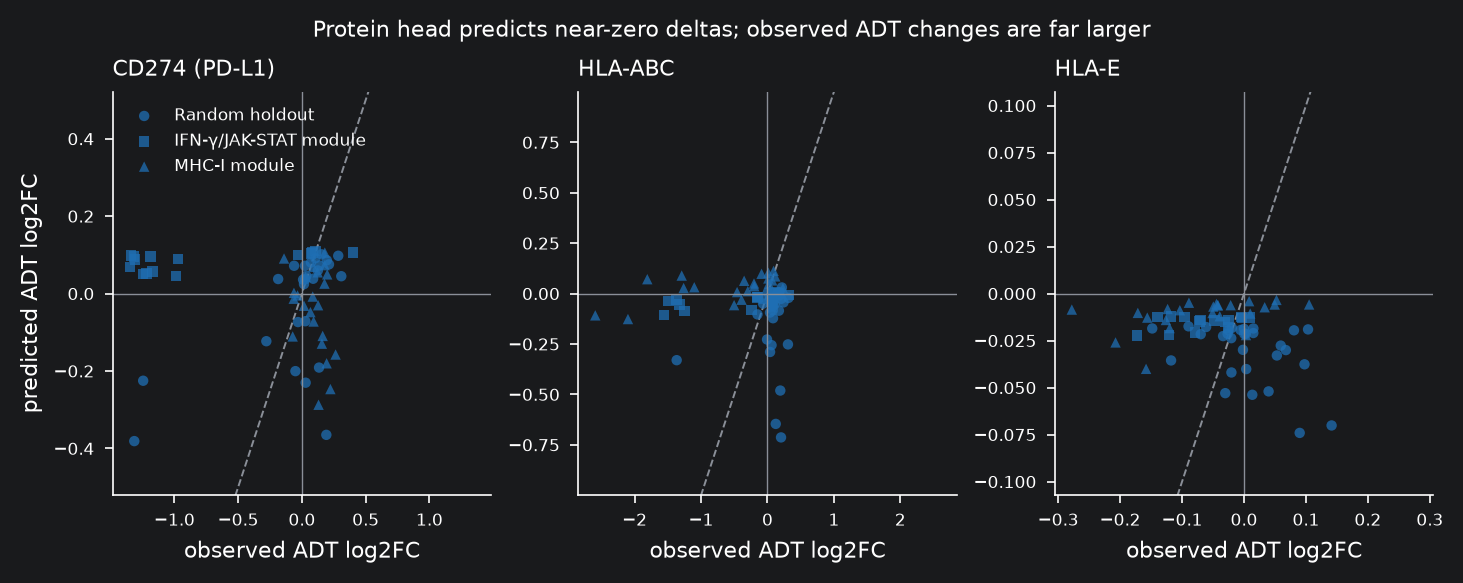

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.8), constrained_layout=True)
FOCL = {'CD274': 'CD274 (PD-L1)', 'HLA_A': 'HLA-ABC', 'HLA_E': 'HLA-E'}
mk = {'random': 'o', 'module_IFNG_JAK_STAT': 's', 'module_MHC_I': '^'}
for ax, a in zip(axes, ['CD274', 'HLA_A', 'HLA_E']):
    j = adt_cols.index(a)
    for sp in SPL:
        d = diag[sp]
        ax.scatter(Y_adt[d['te_idx'], j], d['nn_adt'][:, j], s=14, marker=mk[sp], color=COL['nn'],
                   alpha=0.75, edgecolors='none', label=SPLT[sp].split('\n')[0] if a == 'CD274' else None)
    lim = max(np.abs(Y_adt[:, j]).max(), 0.2) * 1.1
    ax.axhline(0, lw=0.5, color=META_GREY); ax.axvline(0, lw=0.5, color=META_GREY)
    ax.plot([-lim, lim], [-lim, lim], lw=0.7, ls='--', color=META_GREY, zorder=0)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim * 0.35, lim * 0.35)
    ax.set_title(FOCL[a], fontsize=8); ax.set_xlabel('observed ADT log2FC'); ax.margins(0.04)
axes[0].set_ylabel('predicted ADT log2FC')
axes[0].legend(frameon=False, fontsize=6, loc='upper left')
fig.suptitle('Protein head predicts near-zero deltas; observed ADT changes are far larger', fontsize=8)
fig.savefig(FIGURES / 'task3_adt_head.png', dpi=300)

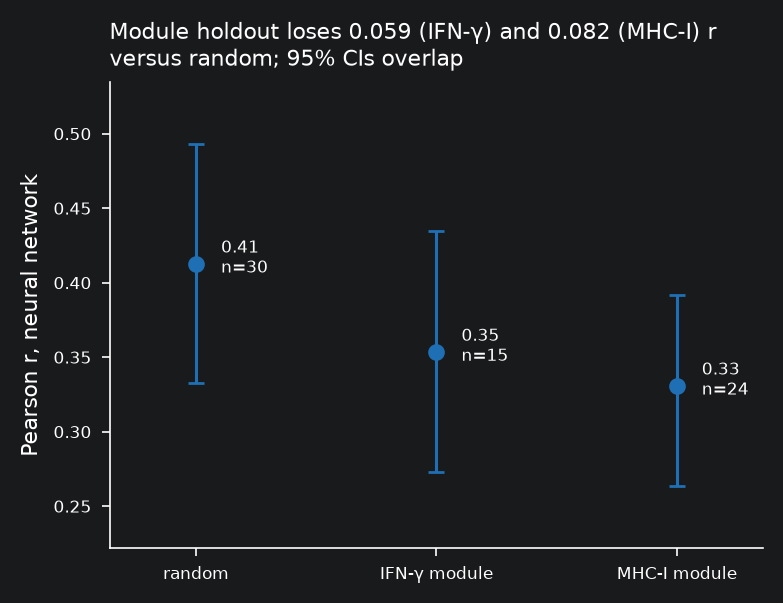

In [54]:
md_nn = (metrics_df[(metrics_df['metric'] == 'rna_pearson_r') &
                    (metrics_df['boot_over'] == 'perturbation_rows') &
                    (metrics_df['model'] == 'nn')].set_index('split').reindex(SPL))
fig, ax = plt.subplots(figsize=(3.8, 2.9), constrained_layout=True)
xs = np.arange(3)
ax.errorbar(xs, md_nn['mean'], yerr=[md_nn['mean'] - md_nn['ci_lo'], md_nn['ci_hi'] - md_nn['mean']],
            fmt='o', ms=5, lw=0, elinewidth=1.1, capsize=3, color=COL['nn'])
for x, (m, n) in enumerate(zip(md_nn['mean'], md_nn['n'])):
    ax.annotate(f'{m:.2f}\nn={int(n)}', (x, m), textcoords='offset points', xytext=(9, -3), fontsize=6)
ax.set_xticks(xs); ax.set_xticklabels(['random', 'IFN-γ module', 'MHC-I module'])
ax.set_ylabel('Pearson r, neural network'); ax.margins(0.18)
gap_i = md_nn.loc['random', 'mean'] - md_nn.loc['module_IFNG_JAK_STAT', 'mean']
gap_m = md_nn.loc['random', 'mean'] - md_nn.loc['module_MHC_I', 'mean']
ax.set_title(f'Module holdout loses {gap_i:.3f} (IFN-γ) and {gap_m:.3f} (MHC-I) r\nversus random; 95% CIs overlap', fontsize=8)
fig.savefig(FIGURES / 'task3_holdout_gap.png', dpi=300)

In [55]:
splits_out = {
    'selection': {'n': 50, 'perturbations': SEL50,
                  'criteria': {'a_min_single_pert_cells_all3conditions': 50,
                               'b_signal_statistic': 'n_sig_genes = # expressed genes with |log2FC| > 3*SE, summed over the 3 conditions',
                               'c_module_spanning': '13 mandatory (5 IFN-γ/JAK-STAT core + 8 MHC-I); remaining 37 by top n_sig_genes'}},
    'holdouts': {'random': {'n': 10, 'perturbations': random_holdout, 'seed': 20240805},
                 'module_IFNG_JAK_STAT': {'n': 5, 'perturbations': module_ifn},
                 'module_MHC_I': {'n': 8, 'perturbations': module_mhc}},
    'train_sets': TRAIN,
    'cv': 'leave-one-perturbation-out inside each training set only',
    'conditions': CONDS}
json.dump(splits_out, open(f'{DATA}/task3_splits.json', 'w'), indent=1)
print('wrote task3_splits.json, task3_metrics.csv, task3_per_perturbation.csv, task3_features.parquet')

wrote task3_splits.json, task3_metrics.csv, task3_per_perturbation.csv, task3_features.parquet
